In [3]:
from keras.datasets import mnist
from keras import layers, models
from keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

In [4]:
(train_data, train_labels), (test_data, test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
x_train = train_data.reshape((60000, 28*28))
x_train = x_train.astype('float32') / 255

x_test = test_data.reshape((10000, 28*28))
x_test = x_test.astype('float32') / 255

y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

In [6]:
model = models.Sequential()
model.add(layers.Dense(512, activation='relu', input_shape=(784,)))
model.add(layers.Dense(10, activation='softmax'))

model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.fit(x_train, y_train, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9247 - loss: 0.2646
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9686 - loss: 0.1067
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9790 - loss: 0.0703
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9850 - loss: 0.0505
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9893 - loss: 0.0376


In [8]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9792 - loss: 0.0675
Accuracy: 0.979200005531311


In [9]:
uploaded = files.upload()

Saving 6.png to 6 (1).png


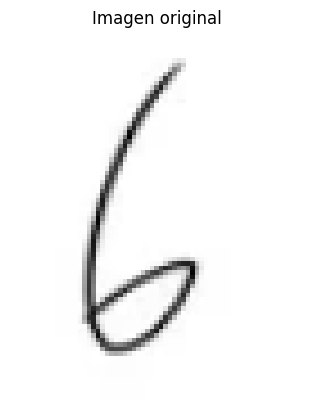

In [10]:
filename = list(uploaded.keys())[0]

img = Image.open(filename).convert('L')

plt.imshow(img, cmap='gray')
plt.title("Imagen original")
plt.axis('off')
plt.show()

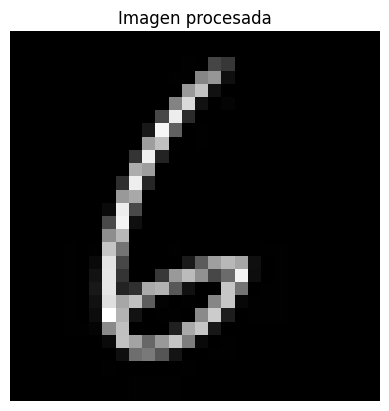

In [11]:
# Redimensionar
img = img.resize((28, 28))

# Convertir a array
img_array = np.array(img)

# Invertir colores (MNIST usa fondo negro)
img_array = 255 - img_array

# Normalizar
img_array = img_array.astype('float32') / 255

# Aplanar
img_array = img_array.reshape(1, 784)

# Ver cómo lo ve el modelo
plt.imshow(img_array.reshape(28,28), cmap='gray')
plt.title("Imagen procesada")
plt.axis('off')
plt.show()

In [12]:
prediction = model.predict(img_array)

print("Probabilidades:", prediction)
print("Número predicho:", np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Probabilidades: [[0.24922928 0.02404844 0.14596526 0.00298544 0.03551178 0.02108582
  0.47269133 0.00612236 0.03136405 0.01099626]]
Número predicho: 6
